# Pipeline 3: LightOnOCR + LLM (Ministral 8B via Mistral API)

This notebook mirrors the EasyOCR pipeline exactly, but replaces **EasyOCR** with **LightOnOCR** as the text extraction engine.

## Pipeline Flow
```
Image → LightOnOCR → Raw Text → Ministral-8B (API) → Structured Output → Evaluation
```

## 0. Install Dependencies

In [1]:
# Install required packages
# !uv pip install "transformers>=5.0.0" torch pillow mistralai python-dotenv matplotlib -q

## 1. Setup and Imports

In [2]:
import sys
import os
import json
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from mistralai import Mistral
from dotenv import load_dotenv

# Project root is two levels up from this notebook:
#   experiments/lightonocr_pipelines/ -> experiments/ -> project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Import our modules
import llm_processing.prompts as _prompts_mod
importlib.reload(_prompts_mod)
from llm_processing.prompts import get_prompt, PROMPTS

import evaluation.llm_metrics as _metrics_mod
importlib.reload(_metrics_mod)
from evaluation.llm_metrics import (
    calculate_rouge_scores,
    calculate_bertscore,
    extract_medical_terms,
    calculate_information_preservation,
)

print("\u2713 Imports successful")
print(f"  PROJECT_ROOT = {PROJECT_ROOT}")

/home/bashar/bachelor-thesis-nursing-agents/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports successful
  PROJECT_ROOT = /home/bashar/bachelor-thesis-nursing-agents


## 2. Initialize LightOnOCR

In [3]:
import torch
from transformers import LightOnOcrForConditionalGeneration, LightOnOcrProcessor

# Initialize LightOnOCR model and processor
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32 if device == "mps" else torch.bfloat16
MODEL_ID = "lightonai/LightOnOCR-2-1B"

print("Initializing LightOnOCR model...")
print("This may take a moment on first run (downloading ~2 GB model)...")
model = LightOnOcrForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype=dtype).to(device)
processor = LightOnOcrProcessor.from_pretrained(MODEL_ID)
model.eval()

def run_lightonocr_ocr(image_input):
    """Run LightOnOCR on a PIL image or image path and return extracted text."""
    image_url = str(image_input)
    conversation = [{"role": "user", "content": [{"type": "image", "url": image_url}]}]
    inputs = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = {
        k: v.to(device=device, dtype=dtype) if v.is_floating_point() else v.to(device)
        for k, v in inputs.items()
    }
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=2048)
    generated_ids = output_ids[0, inputs["input_ids"].shape[1]:]
    return processor.decode(generated_ids, skip_special_tokens=True).strip()

print("✓ LightOnOCR model and processor initialized")

Initializing LightOnOCR model...
This may take a moment on first run (downloading ~2 GB model)...


You are using a model of type `mistral3` to instantiate a model of type `lighton_ocr`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
Loading weights: 100%|██████████| 532/532 [00:00<00:00, 2688.52it/s]


✓ LightOnOCR model and processor initialized


## 3. Setup Mistral API

In [4]:
# Load API key from .env at project root
env_path = PROJECT_ROOT / '.env'
if env_path.exists():
    load_dotenv(env_path)
    print(f"\u2713 Loaded .env from {env_path}")
else:
    print(f"\u26a0 .env file not found at {env_path}")
    print("  Set MISTRAL_API_KEY manually or create a .env file")

api_key = os.getenv('MISTRAL_API_KEY')
if not api_key:
    raise ValueError("MISTRAL_API_KEY not found. Set it in your .env file or environment.")

client = Mistral(api_key=api_key)
print("\u2713 Mistral client initialized")

MODEL_NAME = 'ministral-8b-latest'
print(f"  Model: {MODEL_NAME}")

## 4. Load Sample Image and Ground Truth

In [5]:
# Load test set
test_set_path = PROJECT_ROOT / 'data' / 'test_set_500.json'
with open(test_set_path, 'r', encoding='utf-8') as f:
    test_set = json.load(f)

# Select first sample
sample = test_set['samples'][117]
print(f"Sample ID: {sample['sample_id']}")
print(f"Font: {sample['font']}")
print(f"Scenario: {sample['scenario']}")

# Load image
image_path = PROJECT_ROOT / sample['image_path']
image = Image.open(image_path)

# Load ground truth label
label_path = PROJECT_ROOT / sample['label_path']
with open(label_path, 'r', encoding='utf-8') as f:
    ground_truth = json.load(f)

# Load reference_summary from scenarios.json
scenarios_path = PROJECT_ROOT / 'data' / 'synthetic' / 'scenarios.json'
with open(scenarios_path, 'r', encoding='utf-8') as f:
    scenarios = json.load(f)

scenario_lookup = {s['patient']: s for s in scenarios}
current_scenario = scenario_lookup.get(sample['scenario'], {})
reference_summary = current_scenario.get('reference_summary', '')

if not reference_summary:
    print(f"\u26a0 No reference_summary found for scenario '{sample['scenario']}'")
else:
    print(f"\u2713 Reference summary loaded ({len(reference_summary)} chars)")

print(f"\nImage size: {image.size}")
print(f"Text length: {len(ground_truth['full_text'])} characters")

Sample ID: sample_0154
Font: HomemadeApple-Regular
Scenario: Elisabeth Weber
✓ Reference summary loaded (798 chars)

Image size: (1240, 1754)
Text length: 1291 characters


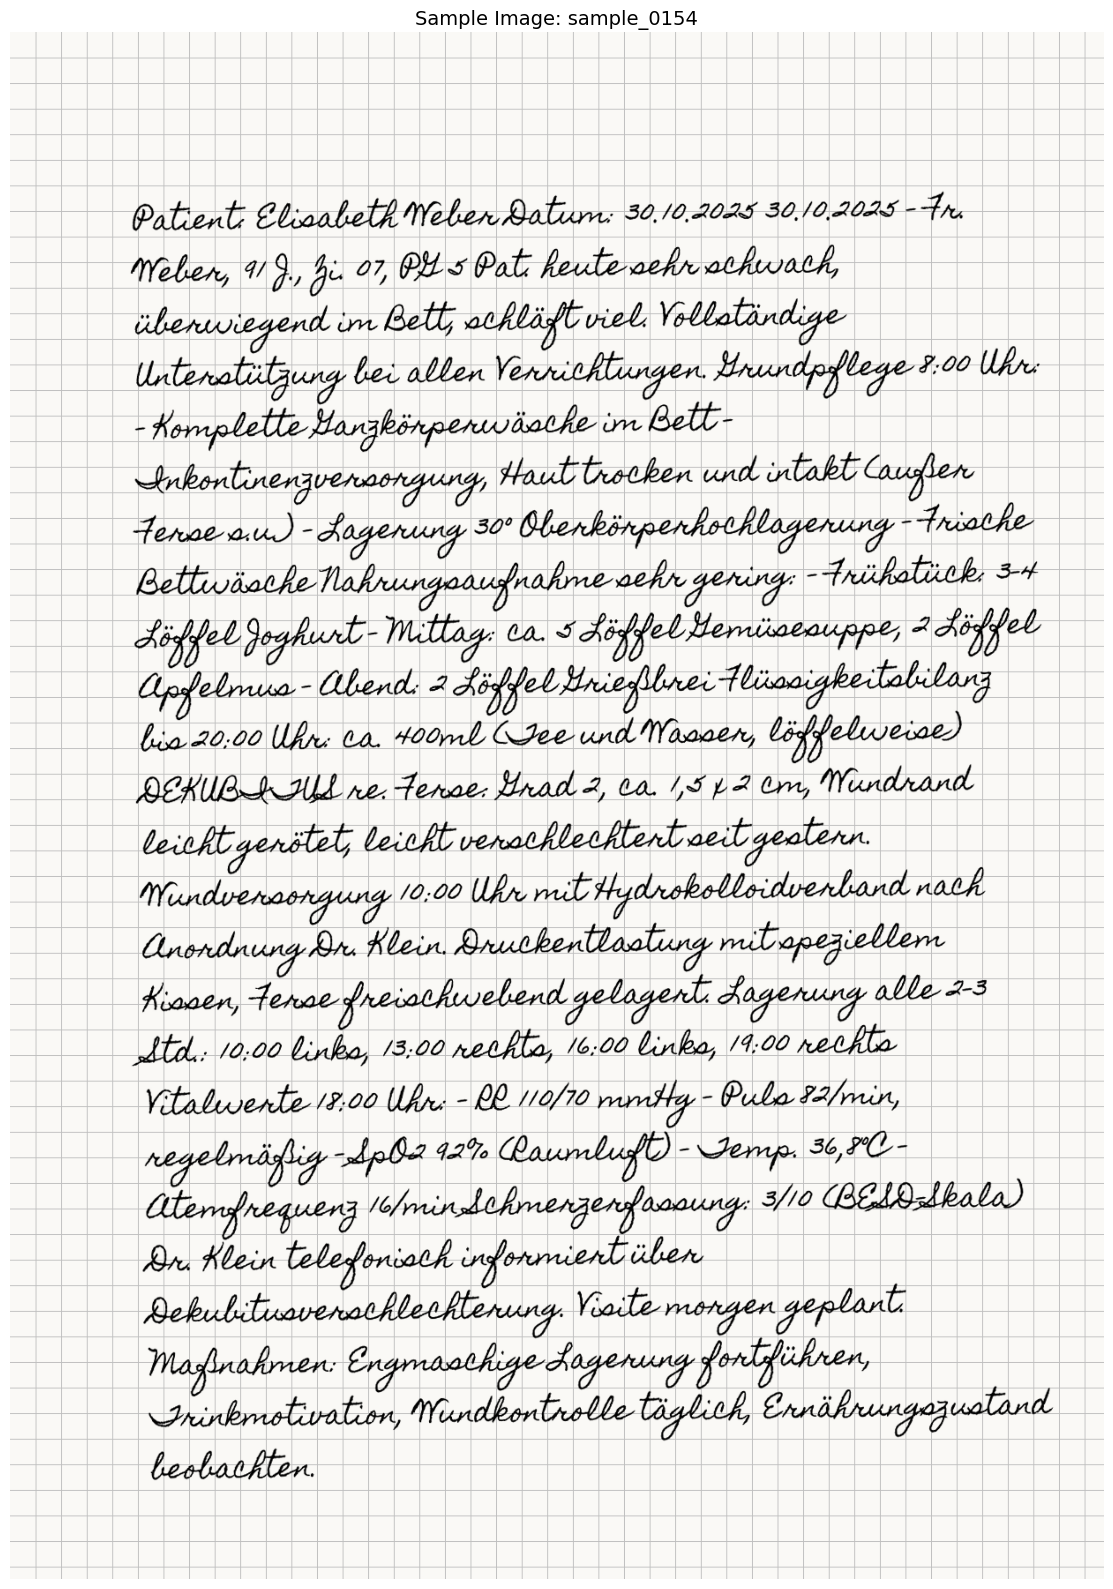

In [6]:
# Display the image
plt.figure(figsize=(12, 16))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title(f"Sample Image: {sample['sample_id']}", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Display ground truth
print("="*80)
print("GROUND TRUTH TEXT:")
print("="*80)
print(ground_truth['original_notes'])
print("="*80)

GROUND TRUTH TEXT:
30.10.2025 - Fr. Weber, 91 J., Zi. 07, PG 5

Pat. heute sehr schwach, überwiegend im Bett, schläft viel. Vollständige Unterstützung bei allen Verrichtungen.

Grundpflege 8:00 Uhr:
- Komplette Ganzkörperwäsche im Bett
- Inkontinenzversorgung, Haut trocken und intakt (außer Ferse s.u.)
- Lagerung 30° Oberkörperhochlagerung
- Frische Bettwäsche

Nahrungsaufnahme sehr gering:
- Frühstück: 3-4 Löffel Joghurt
- Mittag: ca. 5 Löffel Gemüsesuppe, 2 Löffel Apfelmus
- Abend: 2 Löffel Grießbrei

Flüssigkeitsbilanz bis 20:00 Uhr: ca. 400ml (Tee und Wasser, löffelweise)

DEKUBITUS re. Ferse:
Grad 2, ca. 1,5 x 2 cm, Wundrand leicht gerötet, leicht verschlechtert seit gestern. Wundversorgung 10:00 Uhr mit Hydrokolloidverband nach Anordnung Dr. Klein. Druckentlastung mit speziellem Kissen, Ferse freischwebend gelagert.

Lagerung alle 2-3 Std.: 10:00 links, 13:00 rechts, 16:00 links, 19:00 rechts

Vitalwerte 18:00 Uhr:
- RR 110/70 mmHg
- Puls 82/min, regelmäßig
- SpO2 92% (Raumluft)


## 5. Run LightOnOCR

In [8]:
# Run LightOnOCR
print("Running LightOnOCR...")
ocr_text = run_lightonocr_ocr(image_path)

print(f"✓ OCR completed")
print(f"Total OCR text length: {len(ocr_text)} characters")

Running LightOnOCR...
✓ OCR completed
Total OCR text length: 1300 characters


In [9]:
# Display OCR output preview
print("="*80)
print("LightOnOCR OUTPUT (preview):")
print("="*80)
preview = ocr_text.replace("\n", " ").strip()
print(preview[:1200] + ("..." if len(preview) > 1200 else ""))
print("="*80)

LightOnOCR OUTPUT (preview):
Patient Elisabeth Weber Datum: 30.10.2025 30.10.2025 - Fr. Weber, 91 J., zi 07, PH 5 Pat. heute sehr schwach, überwiegend im Bett, schläft viel. Vollständige Unterstützung bei allen Verrichtungen. Grundpflege 8:00 Uhr:  - Komplette Gangkörperwäsche im Bett- - Inkontinenzversorgung, Haut trocken und intakt (außer Ferse s.u.) - Lagerung 30° Oberkörperhochlagerung - Frische Bettwäsche Nahrungsaufnahme sehr gering: - Frühstück: 3-4 Löffel Joghurt - Mittag: ca. 5 Löffel Gemüsesuppe, 2 Löffel Apfelmus - Abend: 2 Löffel Griefsbrei Flüssigkeitsbilanz bis 20:00 Uhr: ca. 400ml (Jee und Wasser, löffelweise)  DEKUB & JBL re. Ferse: Grad 2, ca. 1,5 x 2 cm, Mundrand leicht gerötet, leicht verschlechtert seit gestern.  Wundversorgung 10:00 Uhr mit Hydrokolloidverband nach Anordnung Dr. Klein. Druckentlastung mit speziellem Kissen, Ferse freischwebend gelagert. Lagerung alle 2-3 Std.: 10:00 links, 13:00 rechts, 16:00 links, 19:00 rechts  Vitalwerte 18:00 Uhr: - RR 110/70 m

In [10]:
# Display full OCR text
print("="*80)
print("FULL OCR TEXT:")
print("="*80)
print(ocr_text)
print("="*80)

FULL OCR TEXT:
Patient Elisabeth Weber Datum: 30.10.2025 30.10.2025 - Fr. Weber, 91 J., zi 07, PH 5 Pat. heute sehr schwach, überwiegend im Bett, schläft viel. Vollständige Unterstützung bei allen Verrichtungen. Grundpflege 8:00 Uhr:

- Komplette Gangkörperwäsche im Bett-
- Inkontinenzversorgung, Haut trocken und intakt (außer Ferse s.u.) - Lagerung 30° Oberkörperhochlagerung - Frische Bettwäsche Nahrungsaufnahme sehr gering: - Frühstück: 3-4 Löffel Joghurt - Mittag: ca. 5 Löffel Gemüsesuppe, 2 Löffel Apfelmus - Abend: 2 Löffel Griefsbrei Flüssigkeitsbilanz bis 20:00 Uhr: ca. 400ml (Jee und Wasser, löffelweise)

DEKUB & JBL re. Ferse: Grad 2, ca. 1,5 x 2 cm, Mundrand leicht gerötet, leicht verschlechtert seit gestern.

Wundversorgung 10:00 Uhr mit Hydrokolloidverband nach Anordnung Dr. Klein. Druckentlastung mit speziellem Kissen, Ferse freischwebend gelagert. Lagerung alle 2-3 Std.: 10:00 links, 13:00 rechts, 16:00 links, 19:00 rechts

Vitalwerte 18:00 Uhr: - RR 110/70 mmHg - Puls 82/

## 6. Check Available Prompts

In [11]:
print("Available prompts:")
print("="*80)
for name, prompt in PROMPTS.items():
    print(f"\n{name}:")
    print(f"  {prompt['description']}")
print("="*80)

Available prompts:

nursing_summary:
  Summarize noisy OCR nursing notes and extract exact key features

critical_info_extraction:
  Extract critical medical information only

care_plan_generation:
  Generate a care plan based on the notes

risk_assessment:
  Assess patient risks from nursing notes

simple_summary:
  Simple one-paragraph summary


## 7. Process OCR Text with Mistral (Ministral-8B)

In [12]:
def run_mistral_pipeline(ocr_text: str) -> str:
    """Call ministral-8b-latest with the nursing_summary prompt."""
    prompt_config = PROMPTS["nursing_summary"]
    system_prompt = prompt_config["system"]
    user_message = prompt_config["task"].format(text=ocr_text)

    response = client.chat.complete(
        model=MODEL_NAME,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user',   'content': user_message},
        ],
        temperature=0.0,
        random_seed=42,
    )
    return response.choices[0].message.content

print("\u2713 run_mistral_pipeline() defined")
print(f"Processing OCR text with {MODEL_NAME}...")
llm_output = run_mistral_pipeline(ocr_text)
print("\u2713 LLM processing completed")

✓ run_mistral_pipeline() defined
Processing OCR text with ministral-8b-latest...
✓ LLM processing completed


In [13]:
# Display LLM output
print("="*80)
print(f"LLM OUTPUT ({MODEL_NAME} - Nursing Summary):")
print("="*80)
print(llm_output)
print("="*80)

LLM OUTPUT (ministral-8b-latest - Nursing Summary):
1. **Zusammenfassung**:
Die Pflegenotiz dokumentiert den Zustand der 91-jährigen Patientin Elisabeth Weber (Zimmer 07) vom **30.10.2025**. Sie ist stark eingeschränkt, überwiegend bettlägerig und benötigt vollständige Unterstützung bei allen Verrichtungen. Die Grundpflege erfolgte um **8:00 Uhr** mit einer kompletten Bettwäsche, Inkontinenzversorgung (Haut intakt, außer **Dekubitus Grad 2 an der rechten Ferse**, 1,5 × 2 cm, leicht verschlechtert) und Oberkörperhochlagerung in **30°**. Die Nahrungsaufnahme war minimal (Joghurt, Suppe, Brei), die Flüssigkeitsbilanz bis 20:00 Uhr betrug **400 ml**. Die Vitalwerte um **18:00 Uhr** zeigten: **RR 110/70 mmHg**, Puls **82/min**, SpO2 **92%**, Temperatur **36,8°C**, Atemfrequenz **16/min** und Schmerzen **3/10 (BESD-Skala)**. Die Wundversorgung erfolgte um **10:00 Uhr** mit Hydrokolloidverband; Lagerung alle 2–3 Stunden mit Druckentlastung. Dr. Klein wurde telefonisch über die Dekubitusversch

## 8. Evaluate LLM Output

In [14]:
# Calculate ROUGE scores
rouge_scores = calculate_rouge_scores(reference=reference_summary, hypothesis=llm_output)

print("ROUGE Scores (LLM output vs Reference Summary):")
print("="*80)
for metric, prefix in [('ROUGE-1', 'rouge1'), ('ROUGE-2', 'rouge2'), ('ROUGE-L', 'rougeL')]:
    print(f"{metric}:")
    print(f"  Precision: {rouge_scores[f'{prefix}_precision']:.2f}%")
    print(f"  Recall:    {rouge_scores[f'{prefix}_recall']:.2f}%")
    print(f"  F1:        {rouge_scores[f'{prefix}_f1']:.2f}%")
print("="*80)

ROUGE Scores (LLM output vs Reference Summary):
ROUGE-1:
  Precision: 28.01%
  Recall:    83.33%
  F1:        41.93%
ROUGE-2:
  Precision: 17.98%
  Recall:    53.78%
  F1:        26.95%
ROUGE-L:
  Precision: 18.77%
  Recall:    55.83%
  F1:        28.09%


In [15]:
# Calculate BERTScore
bert_scores = calculate_bertscore(reference=reference_summary, hypothesis=llm_output)

print("BERTScore (LLM output vs Reference Summary):")
print("="*80)
print(f"  Precision: {bert_scores['bertscore_precision']:.2f}%")
print(f"  Recall:    {bert_scores['bertscore_recall']:.2f}%")
print(f"  F1:        {bert_scores['bertscore_f1']:.2f}%")
print("="*80)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2840.64it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore (LLM output vs Reference Summary):
  Precision: 21.00%
  Recall:    34.70%
  F1:        27.71%


/home/bashar/bachelor-thesis-nursing-agents/.venv/lib/python3.11/site-packages/bert_score/score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  baselines = torch.from_numpy(


In [16]:
# Medical term preservation
medical_terms_ref = extract_medical_terms(reference_summary)
medical_terms_hyp = extract_medical_terms(llm_output)

preservation = calculate_information_preservation(reference=reference_summary, summary=llm_output)

missing_terms = medical_terms_ref - medical_terms_hyp
extra_terms   = medical_terms_hyp - medical_terms_ref

print("Medical Term Preservation (vs Reference Summary):")
print("="*80)
print(f"Terms in reference: {preservation['terms_in_reference']}")
print(f"Terms in summary:   {preservation['terms_in_summary']}")
print(f"Terms preserved:    {preservation['terms_preserved']}")
print(f"Precision:          {preservation['medical_term_precision']:.2f}%")
print(f"Recall:             {preservation['medical_term_recall']:.2f}%")
print(f"F1:                 {preservation['medical_term_f1']:.2f}%")

if missing_terms:
    print(f"\nMissing terms ({len(missing_terms)}):")
    for term in sorted(missing_terms)[:10]:
        print(f"  - {term}")
if extra_terms:
    print(f"\nExtra terms ({len(extra_terms)}):")
    for term in sorted(extra_terms)[:10]:
        print(f"  - {term}")
print("="*80)

Medical Term Preservation (vs Reference Summary):
Terms in reference: 6
Terms in summary:   12
Terms preserved:    5
Precision:          41.67%
Recall:             83.33%
F1:                 55.56%

Missing terms (1):
  - schmerz

Extra terms (7):
  - atemfrequenz
  - haut
  - patientin
  - schmerzen
  - temperatur
  - täglich
  - wundversorgung


## 9. Visualize Results

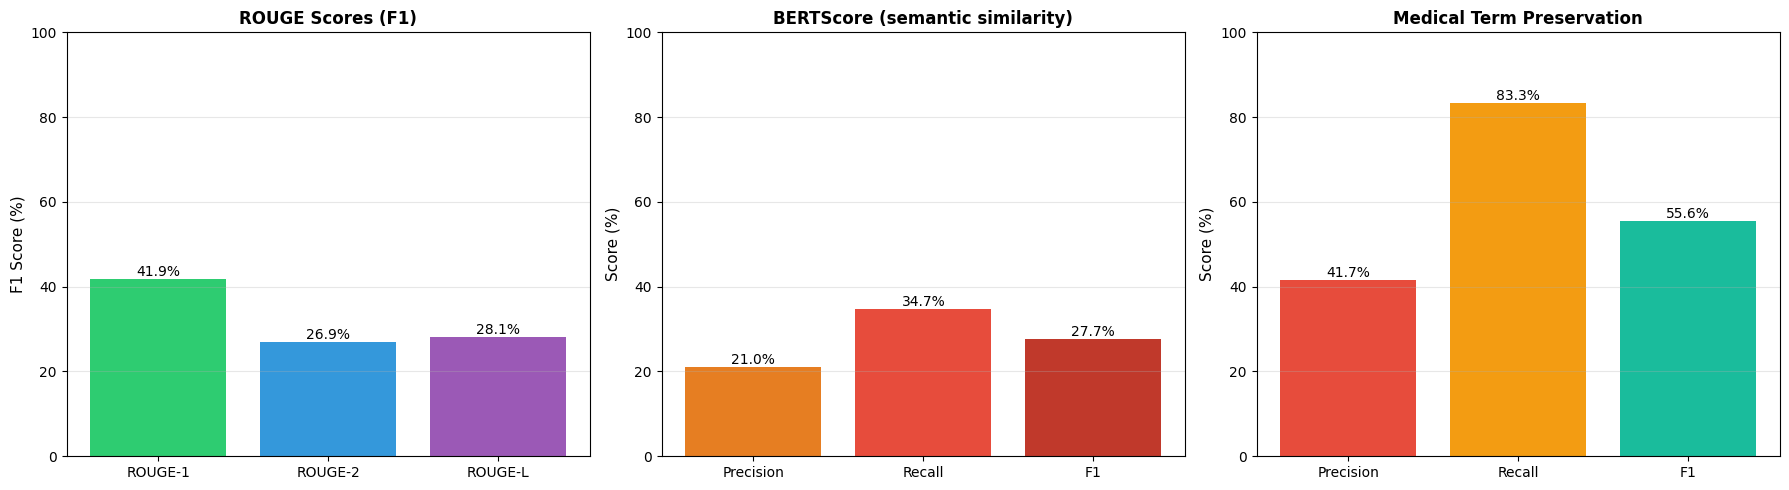

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
rouge_metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
f1_scores = [rouge_scores['rouge1_f1'], rouge_scores['rouge2_f1'], rouge_scores['rougeL_f1']]
bars1 = ax1.bar(rouge_metrics, f1_scores, color=['#2ecc71', '#3498db', '#9b59b6'])
ax1.set_ylabel('F1 Score (%)', fontsize=11)
ax1.set_title('ROUGE Scores (F1)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100); ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h, f'{h:.1f}%', ha='center', va='bottom', fontsize=10)

ax2 = axes[1]
bert_labels = ['Precision', 'Recall', 'F1']
bert_vals   = [bert_scores['bertscore_precision'], bert_scores['bertscore_recall'], bert_scores['bertscore_f1']]
bars2 = ax2.bar(bert_labels, bert_vals, color=['#e67e22', '#e74c3c', '#c0392b'])
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.set_title('BERTScore (semantic similarity)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100); ax2.grid(axis='y', alpha=0.3)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h, f'{h:.1f}%', ha='center', va='bottom', fontsize=10)

ax3 = axes[2]
pres_labels = ['Precision', 'Recall', 'F1']
pres_vals   = [preservation['medical_term_precision'], preservation['medical_term_recall'], preservation['medical_term_f1']]
bars3 = ax3.bar(pres_labels, pres_vals, color=['#e74c3c', '#f39c12', '#1abc9c'])
ax3.set_ylabel('Score (%)', fontsize=11)
ax3.set_title('Medical Term Preservation', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 100); ax3.grid(axis='y', alpha=0.3)
for bar in bars3:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., h, f'{h:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Summary

In [18]:
summary = f"""
{'='*80}
PIPELINE SUMMARY: LightOnOCR + {MODEL_NAME} (Mistral API)
{'='*80}

Sample: {sample['sample_id']}
Font: {sample['font']}
Scenario: {sample['scenario']}

OCR Performance (LightOnOCR):
  - OCR method: LightOnOCR-2-1B
  - OCR text length: {len(ocr_text)} chars
  - Ground truth length: {len(ground_truth['full_text'])} chars

LLM Performance ({MODEL_NAME}):
  - Model: {MODEL_NAME}
  - Prompt: nursing_summary
  - Output length: {len(llm_output)} chars

Evaluation Metrics (LLM output vs reference_summary):
  ROUGE-1 F1:          {rouge_scores['rouge1_f1']:.2f}%
  ROUGE-2 F1:          {rouge_scores['rouge2_f1']:.2f}%
  ROUGE-L F1:          {rouge_scores['rougeL_f1']:.2f}%
  BERTScore F1:        {bert_scores['bertscore_f1']:.2f}%
    Precision:         {bert_scores['bertscore_precision']:.2f}%
    Recall:            {bert_scores['bertscore_recall']:.2f}%

  Medical Terms:
    Precision:         {preservation['medical_term_precision']:.2f}%
    Recall:            {preservation['medical_term_recall']:.2f}%
    F1:                {preservation['medical_term_f1']:.2f}%

{'='*80}
"""
print(summary)


PIPELINE SUMMARY: LightOnOCR + ministral-8b-latest (Mistral API)

Sample: sample_0154
Font: HomemadeApple-Regular
Scenario: Elisabeth Weber

OCR Performance (LightOnOCR):
  - OCR method: LightOnOCR-2-1B
  - OCR text length: 1300 chars
  - Ground truth length: 1291 chars

LLM Performance (ministral-8b-latest):
  - Model: ministral-8b-latest
  - Prompt: nursing_summary
  - Output length: 2747 chars

Evaluation Metrics (LLM output vs reference_summary):
  ROUGE-1 F1:          41.93%
  ROUGE-2 F1:          26.95%
  ROUGE-L F1:          28.09%
  BERTScore F1:        27.71%
    Precision:         21.00%
    Recall:            34.70%

  Medical Terms:
    Precision:         41.67%
    Recall:            83.33%
    F1:                55.56%




## 11. Batch Evaluation — N48 Balanced Set

Same deterministic 48-sample set used across all pipeline notebooks for fair comparison:
- **All 24 fonts** represented (full font coverage)
- **Balanced text lengths** — short (≤300 chars), medium (301–700), long (>700)
- **All paper types, colours, and writing styles** covered

N48 set: 48 samples  (24 fonts · balanced text lengths)



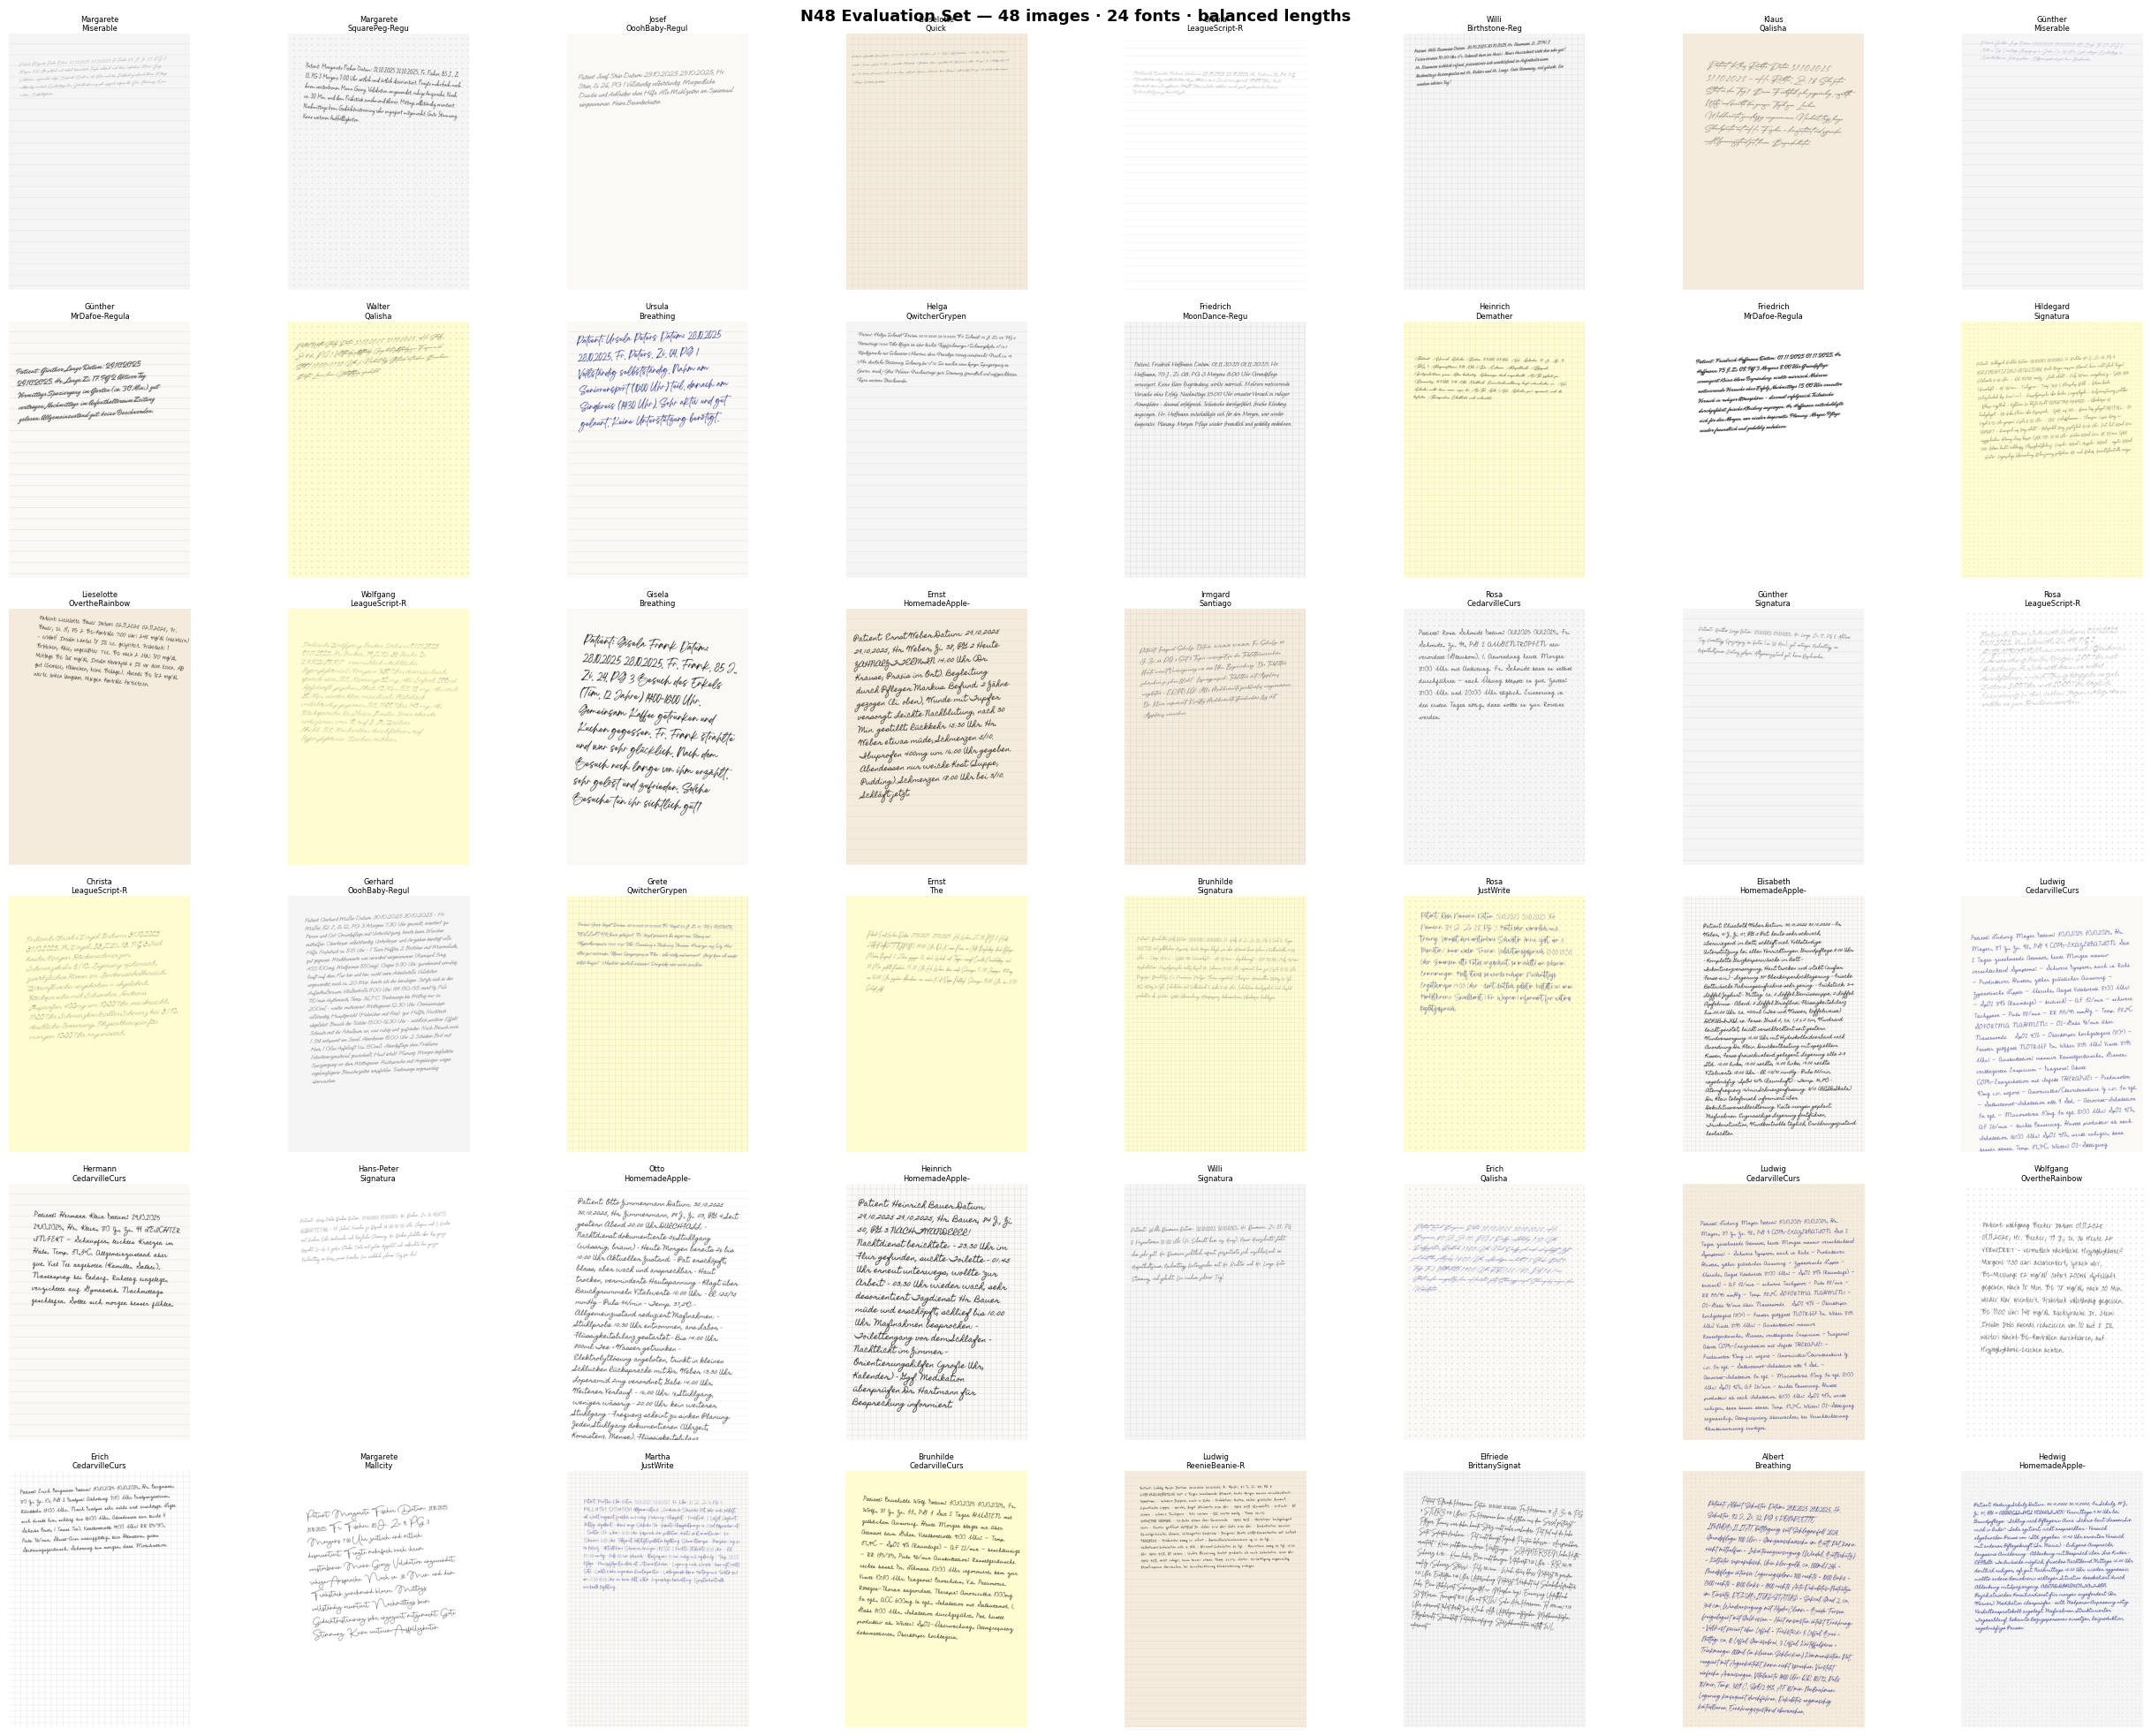

✓ 48 images previewed — run the next cell to start the pipeline


In [19]:
# ── N48 Balanced Evaluation Set ──────────────────────────────────────────────
# 48 images: all 24 fonts covered, balanced across short/medium/long text lengths.
import os

SYNTHETIC_IMAGES = PROJECT_ROOT / 'data' / 'synthetic' / 'output' / 'images'
SYNTHETIC_LABELS = PROJECT_ROOT / 'data' / 'synthetic' / 'output' / 'labels'
N48_DIR          = PROJECT_ROOT / 'data' / 'N30'

N48_SAMPLE_IDS = sorted(p.stem for p in N48_DIR.glob('*.png'))
print(f"N48 set: {len(N48_SAMPLE_IDS)} samples  (24 fonts · balanced text lengths)\n")

# Build metadata list directly from label files (no test_set indexing needed)
n48_samples_meta = []
for sid in N48_SAMPLE_IDS:
    lbl_path = SYNTHETIC_LABELS / f"{sid}.json"
    with open(lbl_path, encoding='utf-8') as _f:
        lbl = json.load(_f)
    font_file = os.path.basename(lbl['generation_parameters'].get('font_path', ''))
    n48_samples_meta.append({
        'sample_id':  sid,
        'image_path': SYNTHETIC_IMAGES / f"{sid}.png",
        'label_path': str(lbl_path),
        'font':       os.path.splitext(font_file)[0],
        'scenario':   lbl.get('patient', ''),
    })

# ── Preview grid ──────────────────────────────────────────────────────────────
n_cols, n_rows = 8, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(26, 20))
fig.suptitle(
    f"N48 Evaluation Set — {len(N48_SAMPLE_IDS)} images · 24 fonts · balanced lengths",
    fontsize=13, fontweight='bold')

for ax, meta in zip(axes.flat, n48_samples_meta):
    img = Image.open(meta['image_path'])
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    font_short    = meta['font'].split()[0][:14]
    patient_first = meta['scenario'].split()[0]
    ax.set_title(f"{patient_first}\n{font_short}", fontsize=6, pad=2)

for ax in axes.flat[len(n48_samples_meta):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"\u2713 {len(N48_SAMPLE_IDS)} images previewed — run the next cell to start the pipeline")

In [20]:
import pandas as pd

# n48_samples_meta is defined in the preview cell above.

print(f"N48 batch: {len(n48_samples_meta)} samples  "
      f"(24 fonts, balanced text lengths)\n")
print(f"{'#':>3}  {'Sample ID':<22} {'R1-F1':>7} {'BERT-F1':>9} {'Med-F1':>8}")
print("\u2500" * 55)

batch_results = []

for i, meta in enumerate(n48_samples_meta):
    curr_scenario = scenario_lookup.get(meta['scenario'], {})
    ref_summary   = curr_scenario.get('reference_summary', '')

    if not ref_summary:
        print(f"{i+1:3d}  {meta['sample_id']:<22}  SKIPPED — no reference_summary")
        continue

    # ── LightOnOCR ────────────────────────────────────────────────────────────
    ocr_txt = run_lightonocr_ocr(meta['image_path'])

    # ── Mistral LLM ──────────────────────────────────────────────────────────
    try:
        llm_out = run_mistral_pipeline(ocr_txt)
    except Exception as e:
        print(f"{i+1:3d}  {meta['sample_id']:<22}  LLM ERROR: {e}")
        continue

    # ── Metrics ──────────────────────────────────────────────────────────────
    rouge = calculate_rouge_scores(reference=ref_summary, hypothesis=llm_out)
    bert  = calculate_bertscore(reference=ref_summary, hypothesis=llm_out)
    pres  = calculate_information_preservation(reference=ref_summary, summary=llm_out)

    batch_results.append({
        'sample_id': meta['sample_id'],
        'font':      meta['font'],
        'scenario':  meta['scenario'],
        **rouge, **bert, **pres,
    })

    print(f"{i+1:3d}  {meta['sample_id']:<22} "
          f"{rouge['rouge1_f1']:>6.1f}% "
          f"{bert['bertscore_f1']:>8.1f}% "
          f"{pres['medical_term_f1']:>7.1f}%")

print(f"\n\u2713 Batch complete — {len(batch_results)}/{len(n48_samples_meta)} samples processed")

N48 batch: 48 samples  (24 fonts, balanced text lengths)

  #  Sample ID                R1-F1   BERT-F1   Med-F1
───────────────────────────────────────────────────────


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2583.38it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  1  sample_0002               7.9%      1.2%     0.0%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2819.88it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  2  sample_0004              43.5%     27.5%    88.9%


...

 46  sample_0865              38.6%     25.1%    66.7%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2558.58it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 47  sample_0869              38.6%     28.2%    58.8%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2693.80it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 48  sample_0883              25.7%     21.8%   100.0%

✓ Batch complete — 48/48 samples processed


In [21]:
if not batch_results:
    print("No results to aggregate.")
else:
    df = pd.DataFrame(batch_results)

    METRIC_COLS = [
        ('ROUGE-1 F1',          'rouge1_f1'),
        ('ROUGE-2 F1',          'rouge2_f1'),
        ('ROUGE-L F1',          'rougeL_f1'),
        ('BERTScore Precision', 'bertscore_precision'),
        ('BERTScore Recall',    'bertscore_recall'),
        ('BERTScore F1',        'bertscore_f1'),
        ('Med.Term Precision',  'medical_term_precision'),
        ('Med.Term Recall',     'medical_term_recall'),
        ('Med.Term F1',         'medical_term_f1'),
    ]

    print(f"Batch Aggregate Statistics — LightOnOCR + {MODEL_NAME}  (N={len(df)})\n")
    print(f"{'Metric':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print("\u2500" * 62)
    for label, col in METRIC_COLS:
        v = df[col]
        print(f"{label:<25} {v.mean():>7.2f}% {v.std():>7.2f}% {v.min():>7.2f}% {v.max():>7.2f}%")

    print(f"\nPer-sample breakdown (N={len(df)}):")
    print(f"{'Sample':<22} {'R1-F1':>7} {'R2-F1':>7} {'RL-F1':>7} {'BERT-F1':>9} {'Med-F1':>8}")
    print("\u2500" * 65)
    for _, row in df.iterrows():
        print(f"{row['sample_id']:<22} {row['rouge1_f1']:>6.1f}% {row['rouge2_f1']:>6.1f}% "
              f"{row['rougeL_f1']:>6.1f}% {row['bertscore_f1']:>8.1f}% {row['medical_term_f1']:>7.1f}%")

Batch Aggregate Statistics — LightOnOCR + ministral-8b-latest  (N=48)

Metric                        Mean      Std      Min      Max
──────────────────────────────────────────────────────────────
ROUGE-1 F1                  34.58%   11.69%    5.56%   49.01%
ROUGE-2 F1                  17.34%    7.85%    0.00%   30.28%
ROUGE-L F1                  27.74%   10.34%    2.78%   41.11%
BERTScore Precision         16.10%    7.78%   -5.08%   28.64%
BERTScore Recall            33.47%   10.93%    0.79%   44.75%
BERTScore F1                24.44%    8.83%   -2.05%   35.60%
Med.Term Precision          55.34%   34.98%    0.00%  100.00%
Med.Term Recall             78.85%   33.21%    0.00%  100.00%
Med.Term F1                 61.70%   32.84%    0.00%  100.00%

Per-sample breakdown (N=48):
Sample                   R1-F1   R2-F1   RL-F1   BERT-F1   Med-F1
─────────────────────────────────────────────────────────────────
sample_0002               7.9%    1.8%    5.5%      1.2%     0.0%
sample_0004       

/tmp/ipykernel_17935/3686591540.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(rouge_data, labels=['ROUGE-1', 'ROUGE-2', 'ROUGE-L'], patch_artist=True)
/tmp/ipykernel_17935/3686591540.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(bert_data, labels=['Precision', 'Recall', 'F1'], patch_artist=True)
/tmp/ipykernel_17935/3686591540.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax3.boxplot(med_data, labels=['Precision', 'Recall', 'F1'], patch_artist=True)


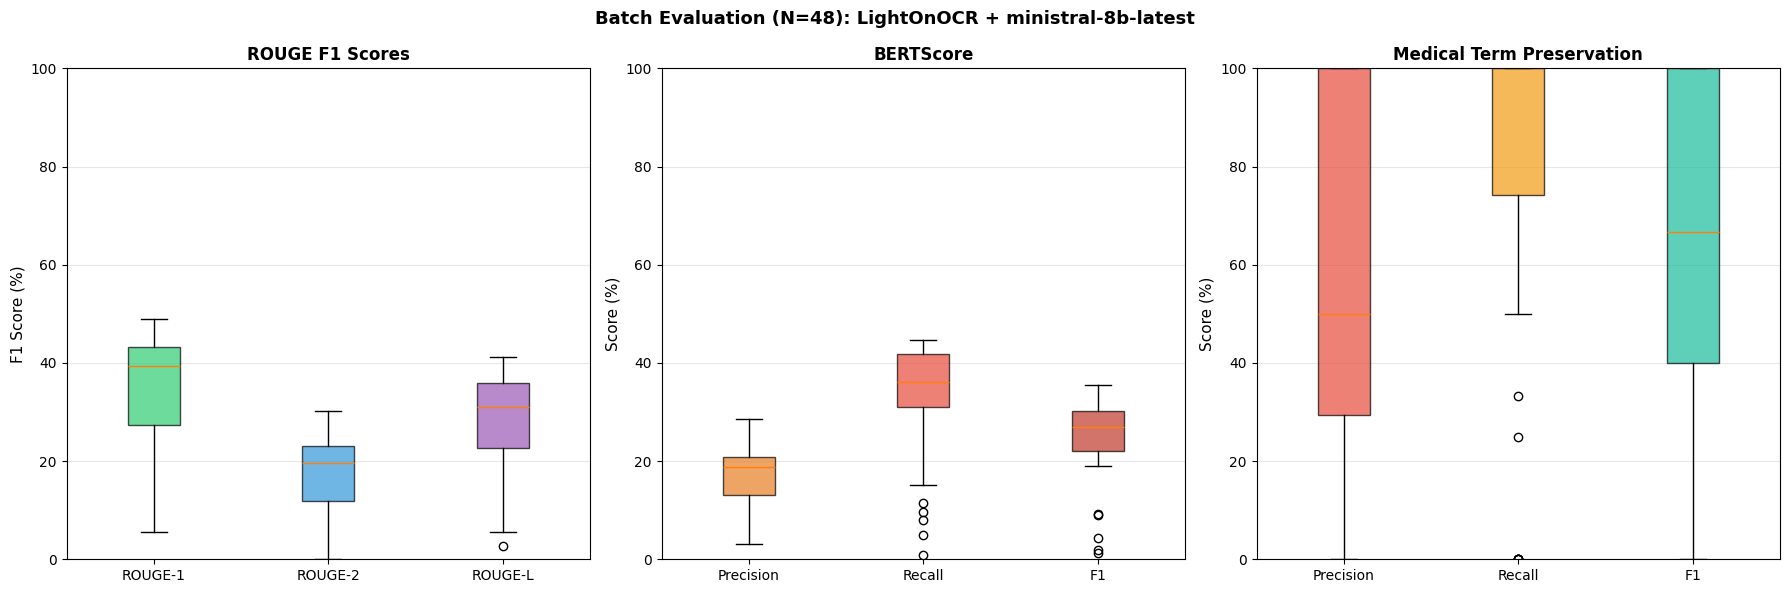

In [22]:
if batch_results:
    df = pd.DataFrame(batch_results)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Batch Evaluation (N={len(df)}): LightOnOCR + {MODEL_NAME}", fontsize=13, fontweight='bold')

    ax1 = axes[0]
    rouge_data = [df['rouge1_f1'], df['rouge2_f1'], df['rougeL_f1']]
    bp1 = ax1.boxplot(rouge_data, labels=['ROUGE-1', 'ROUGE-2', 'ROUGE-L'], patch_artist=True)
    for patch, color in zip(bp1['boxes'], ['#2ecc71', '#3498db', '#9b59b6']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax1.set_ylabel('F1 Score (%)', fontsize=11)
    ax1.set_title('ROUGE F1 Scores', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 100); ax1.grid(axis='y', alpha=0.3)

    ax2 = axes[1]
    bert_data = [df['bertscore_precision'], df['bertscore_recall'], df['bertscore_f1']]
    bp2 = ax2.boxplot(bert_data, labels=['Precision', 'Recall', 'F1'], patch_artist=True)
    for patch, color in zip(bp2['boxes'], ['#e67e22', '#e74c3c', '#c0392b']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax2.set_ylabel('Score (%)', fontsize=11)
    ax2.set_title('BERTScore', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 100); ax2.grid(axis='y', alpha=0.3)

    ax3 = axes[2]
    med_data = [df['medical_term_precision'], df['medical_term_recall'], df['medical_term_f1']]
    bp3 = ax3.boxplot(med_data, labels=['Precision', 'Recall', 'F1'], patch_artist=True)
    for patch, color in zip(bp3['boxes'], ['#e74c3c', '#f39c12', '#1abc9c']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax3.set_ylabel('Score (%)', fontsize=11)
    ax3.set_title('Medical Term Preservation', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, 100); ax3.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [23]:
df.to_csv(PROJECT_ROOT / 'experiments/lightonocr_pipelines/results' / 'n48_lightonocr_ministral8b_results.csv', index=False)